# Referring to Lesson 2.8

### Step 1 — Open a new VSCode terminal and run

conda activate elt

pip install google-cloud-bigquery \
            sqlalchemy-bigquery \
            pyarrow \
            db-dtypes

### Step 2 — Verify installation at terminal
-python -c "from google.cloud import bigquery; print('✅ google-cloud-bigquery OK')"

-python -c "from sqlalchemy import create_engine; print('✅ sqlalchemy OK')"

### Imports:
##### Tools: SQLAlchemy, BigQuery, DuckDB (2.8), Polars (2.8),Pandas, Matplotlib, Seaborn

In [1]:
# ============================================================
# Cell 1: Imports
# Tools: SQLAlchemy, BigQuery, DuckDB (2.8), Polars (2.8),
#        Pandas, Matplotlib, Seaborn
# ============================================================

# Standard
import pandas as pd
import polars as pl
import duckdb
import warnings
warnings.filterwarnings('ignore')

# BigQuery connection
from google.cloud import bigquery
from sqlalchemy import create_engine, text
# Authenticate GCP by running, a one time set up: "gcloud auth application-default login" @ Terminal

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# ── Project Config ─────────────────────────────────────────
PROJECT_ID   = "ntu-sctp-project-2026-may"
DATASET_DWH  = "listenbrainz_dwh"
DATASET_STAR = "listenbrainz_dwh_star"

print("✅ All libraries imported successfully")
print(f"   DuckDB  version : {duckdb.__version__}")
print(f"   Polars  version : {pl.__version__}")
print(f"   Pandas  version : {pd.__version__}")

E0000 00:00:1780734064.090762   70813 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780734064.090826   70813 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780734064.090829   70813 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780734064.090831   70813 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780734064.090832   70813 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


✅ All libraries imported successfully
   DuckDB  version : 1.5.3
   Polars  version : 1.41.2
   Pandas  version : 2.3.3


###  Connect to BigQuery via SQLAlchemy

In [2]:
# ============================================================
# Cell 2: Connect to BigQuery via SQLAlchemy
# Module ref: Step 5 assignment brief
# ============================================================

# SQLAlchemy engine — uses gcloud application-default credentials
engine = create_engine(f"bigquery://{PROJECT_ID}")

# Helper function used throughout the notebook
def bq_query(sql):
    """Execute SQL against BigQuery, return pandas DataFrame"""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# Quick connection test
df_test = bq_query(f"""
    SELECT COUNT(*) AS total_rows
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
""")

print("✅ BigQuery connection successful via SQLAlchemy")
print(f"   fact_listens row count: {df_test['total_rows'].iloc[0]:,}")

✅ BigQuery connection successful via SQLAlchemy
   fact_listens row count: 130,125,945


###  Load Data into DuckDB (Module 2.8)
This is the key 2.8 step — instead of loading 130M rows into pandas memory, we pull summarised samples from BigQuery into DuckDB for fast in-memory analytical queries.

In [3]:
# ============================================================
# Cell 3: Load Data into DuckDB — Out-of-Core Pattern (2.8)
# Why DuckDB: fact_listens has 130M rows — too large for
# pandas directly. We pull pre-aggregated data from BigQuery
# into DuckDB for fast local analytical queries.
# ============================================================

# Step A — Pull summarised datasets from BigQuery into pandas
print("📥 Fetching summarised data from BigQuery...")

# Monthly aggregation (small — safe for pandas)
df_monthly_raw = bq_query(f"""
    SELECT
        listen_year,
        listen_month,
        COUNT(*)                        AS total_listens,
        COUNT(DISTINCT user_name)       AS active_users,
        COUNT(DISTINCT recording_msid)  AS unique_tracks
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
    GROUP BY listen_year, listen_month
    ORDER BY listen_year, listen_month
""")
print(f"   ✅ Monthly data     : {len(df_monthly_raw):,} rows")

# Top artists (small — safe for pandas)
df_artists_raw = bq_query(f"""
    SELECT
        artist_name,
        COUNT(*)                    AS total_listens,
        COUNT(DISTINCT user_name)   AS unique_listeners
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
    GROUP BY artist_name
    ORDER BY total_listens DESC
    LIMIT 100
""")
print(f"   ✅ Top artists      : {len(df_artists_raw):,} rows")

# Peak hours (small — safe for pandas)
df_hours_raw = bq_query(f"""
    SELECT
        listen_hour,
        time_of_day,
        COUNT(*) AS total_listens
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
    GROUP BY listen_hour, time_of_day
    ORDER BY listen_hour
""")
print(f"   ✅ Peak hours       : {len(df_hours_raw):,} rows")

# User metrics (small — 2.7k rows)
df_users_raw = bq_query(f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATASET_STAR}.fct_user_metrics`
    ORDER BY total_listens DESC
""")
print(f"   ✅ User metrics     : {len(df_users_raw):,} rows")

# Weekend vs weekday
df_weekend_raw = bq_query(f"""
    SELECT
        is_weekend,
        COUNT(*)                    AS total_listens,
        COUNT(DISTINCT user_name)   AS active_users
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
    GROUP BY is_weekend
""")
print(f"   ✅ Weekend data     : {len(df_weekend_raw):,} rows")

# Step B — Load all into DuckDB for fast local queries
print("\n📦 Loading into DuckDB...")
con = duckdb.connect()   # in-memory DuckDB instance

con.register("monthly",  df_monthly_raw)
con.register("artists",  df_artists_raw)
con.register("hours",    df_hours_raw)
con.register("users",    df_users_raw)
con.register("weekend",  df_weekend_raw)

# Verify DuckDB tables
tables = con.execute("SHOW TABLES").fetchdf()
print(f"\n✅ DuckDB loaded with {len(tables)} tables:")
for t in tables['name']:
    count = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"   {t:<12} : {count:,} rows")

print("\n✅ Out-of-core setup complete — DuckDB ready for analysis")

📥 Fetching summarised data from BigQuery...
   ✅ Monthly data     : 163 rows
   ✅ Top artists      : 100 rows
   ✅ Peak hours       : 24 rows
   ✅ User metrics     : 2,661 rows
   ✅ Weekend data     : 2 rows

📦 Loading into DuckDB...

✅ DuckDB loaded with 5 tables:
   artists      : 100 rows
   hours        : 24 rows
   monthly      : 163 rows
   users        : 2,661 rows
   weekend      : 2 rows

✅ Out-of-core setup complete — DuckDB ready for analysis


### Analysis 1: Monthly Listening Trends

MONTHLY LISTENING TRENDS — KEY FINDINGS
  Total months of data  : 163
  Peak month            : 2017-07
  Peak month listens    : 1,561,720
  Best year             : 2017
  Best year total       : 16,052,729


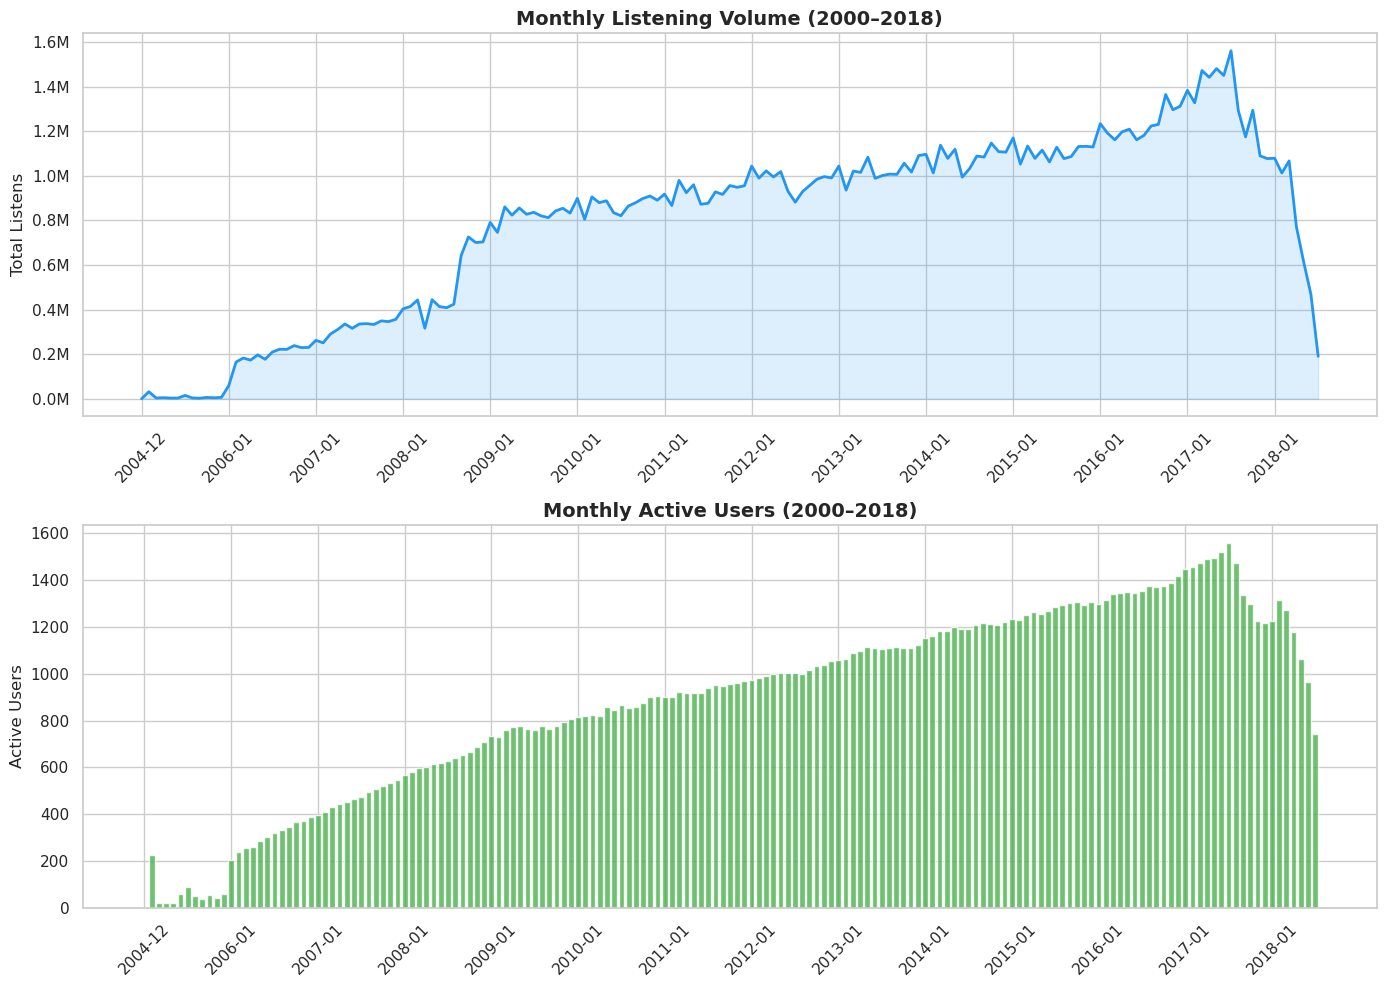


✅ Chart saved to output/monthly_trends.png


In [4]:
# ============================================================
# Cell 4: Monthly Listening Trends
# Business narrative: Growth story for CEO
# ============================================================

# Query DuckDB — no BigQuery cost, instant result
df_monthly = con.execute("""
    SELECT
        listen_year,
        listen_month,
        total_listens,
        active_users,
        unique_tracks,
        -- Create date label for x-axis
        PRINTF('%04d-%02d', listen_year, listen_month) AS year_month
    FROM monthly
    ORDER BY listen_year, listen_month
""").df()

# Convert to Polars for fast computation (2.8)
pl_monthly = pl.from_pandas(df_monthly)

# Calculate month-over-month growth
pl_monthly = pl_monthly.with_columns([
    (pl.col("total_listens").pct_change() * 100)
    .round(1)
    .alias("mom_growth_pct")
])

# Key stats
peak_month = pl_monthly.sort("total_listens", descending=True).head(1)
best_year  = pl_monthly.group_by("listen_year").agg(
    pl.sum("total_listens").alias("yearly_total")
).sort("yearly_total", descending=True).head(1)

print("=" * 55)
print("MONTHLY LISTENING TRENDS — KEY FINDINGS")
print("=" * 55)
print(f"  Total months of data  : {len(pl_monthly)}")
print(f"  Peak month            : {peak_month['year_month'][0]}")
print(f"  Peak month listens    : {peak_month['total_listens'][0]:,}")
print(f"  Best year             : {best_year['listen_year'][0]}")
print(f"  Best year total       : {best_year['yearly_total'][0]:,}")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Monthly listen volume
df_plot = pl_monthly.to_pandas()
axes[0].plot(df_plot['year_month'],
             df_plot['total_listens'],
             color='#2196F3', linewidth=2)
axes[0].fill_between(df_plot['year_month'],
                     df_plot['total_listens'],
                     alpha=0.15, color='#2196F3')
axes[0].set_title('Monthly Listening Volume (2000–2018)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Listens')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
# Show only every 12th label to avoid crowding
tick_positions = range(0, len(df_plot), 12)
axes[0].set_xticks(list(tick_positions))
axes[0].set_xticklabels(
    [df_plot['year_month'].iloc[i] for i in tick_positions],
    rotation=45)

# Plot 2 — Active users per month
axes[1].bar(df_plot['year_month'],
            df_plot['active_users'],
            color='#4CAF50', alpha=0.8)
axes[1].set_title('Monthly Active Users (2000–2018)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Active Users')
axes[1].set_xticks(list(tick_positions))
axes[1].set_xticklabels(
    [df_plot['year_month'].iloc[i] for i in tick_positions],
    rotation=45)

plt.tight_layout()
plt.savefig('output/monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/monthly_trends.png")

###  Analysis 2: Top Artists & Tracks

TOP ARTISTS — KEY FINDINGS
  #1 Radiohead                        515,934 listens  (3.17%)
  #2 The Beatles                      505,803 listens  (3.11%)
  #3 Pink Floyd                       400,546 listens  (2.46%)
  #4 Daft Punk                        394,372 listens  (2.43%)
  #5 Muse                             311,013 listens  (1.91%)


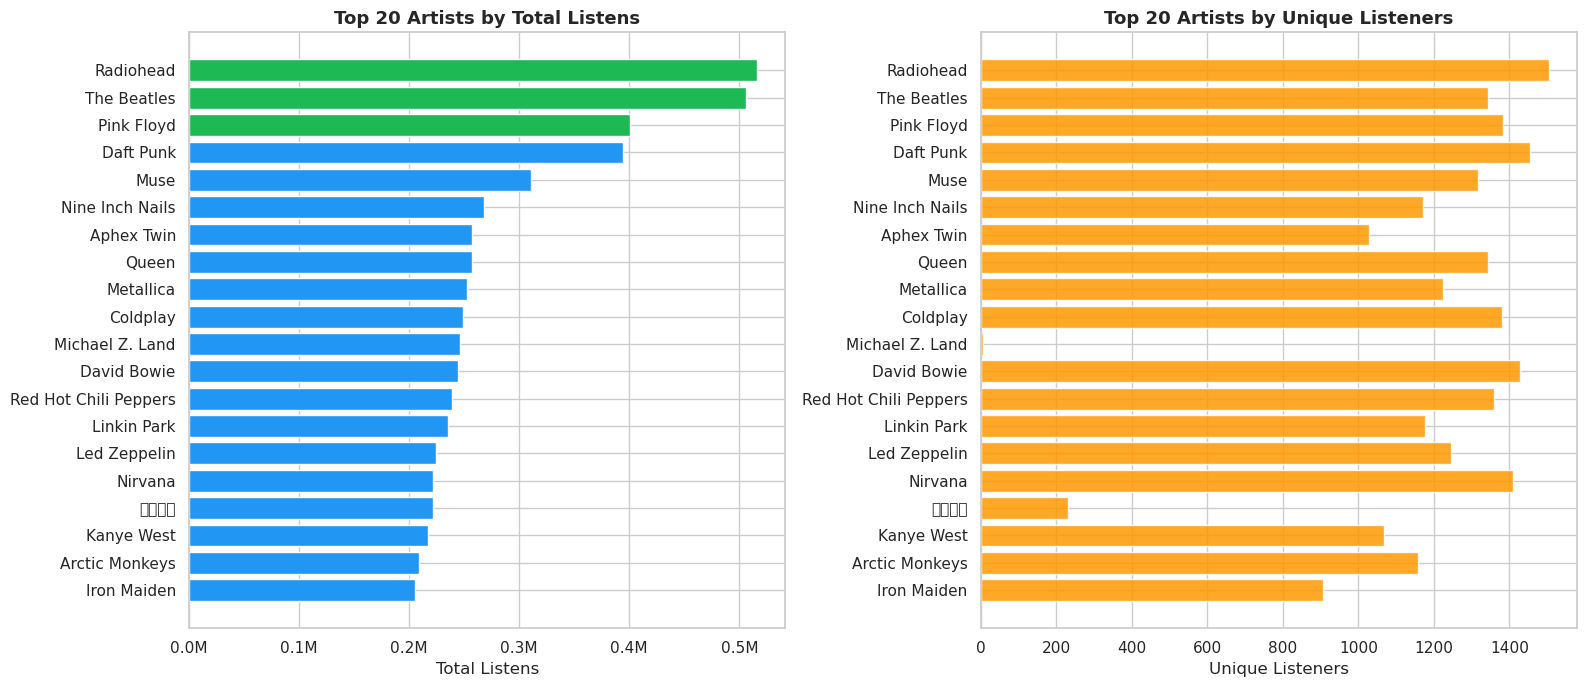


✅ Chart saved to output/top_artists.png


In [5]:
# ============================================================
# Cell 5: Top Artists & Tracks
# Business narrative: Content insights for CMO
# ============================================================

# Query DuckDB
df_top_artists = con.execute("""
    SELECT
        artist_name,
        total_listens,
        unique_listeners,
        ROUND(total_listens * 100.0 /
              SUM(total_listens) OVER (), 2) AS pct_of_total
    FROM artists
    ORDER BY total_listens DESC
    LIMIT 20
""").df()

# Use Polars for analysis
pl_artists = pl.from_pandas(df_top_artists)
top5 = pl_artists.head(5)

print("=" * 55)
print("TOP ARTISTS — KEY FINDINGS")
print("=" * 55)
for i, row in enumerate(top5.iter_rows(named=True), 1):
    print(f"  #{i} {row['artist_name']:<30}"
          f"{row['total_listens']:>10,} listens"
          f"  ({row['pct_of_total']}%)")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1 — Top 20 artists by listens
colors = ['#1DB954' if i < 3 else '#2196F3'
          for i in range(len(df_top_artists))]
axes[0].barh(df_top_artists['artist_name'][::-1],
             df_top_artists['total_listens'][::-1],
             color=colors[::-1])
axes[0].set_title('Top 20 Artists by Total Listens',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Listens')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2 — Top 20 artists by unique listeners
axes[1].barh(df_top_artists['artist_name'][::-1],
             df_top_artists['unique_listeners'][::-1],
             color='#FF9800', alpha=0.85)
axes[1].set_title('Top 20 Artists by Unique Listeners',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unique Listeners')

plt.tight_layout()
plt.savefig('output/top_artists.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/top_artists.png")

### Analysis 3: User Segmentation

USER SEGMENTATION — KEY FINDINGS
Segment               Users   Total Listens   Avg Daily   Avg Days
-----------------------------------------------------------------
  Heavy User            390      68,174,302       138.9      3761
  Regular User        1,170      51,500,532       101.3      2668
  Power User             10       8,366,950       191.9      4324
  Casual User           472       1,947,899        18.3      1033
  Light User            619         136,262        12.4       152


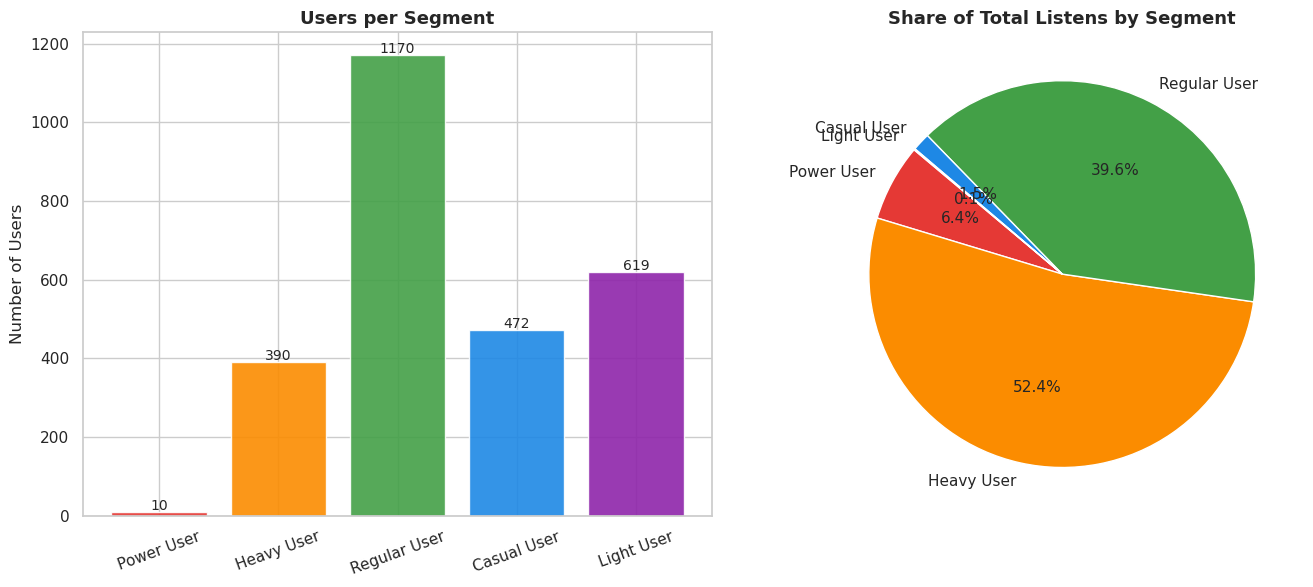


✅ Chart saved to output/user_segments.png


In [6]:
# ============================================================
# Cell 6: User Segmentation by Behaviour
# Business narrative: Audience targeting for CMO,
#                     Premium tier opportunity for CEO
# ============================================================

# Query DuckDB — segment users by engagement level
df_segments = con.execute("""
    SELECT *,
        CASE
            WHEN total_listens >= 500000 THEN 'Power User'
            WHEN total_listens >= 100000 THEN 'Heavy User'
            WHEN total_listens >= 10000  THEN 'Regular User'
            WHEN total_listens >= 1000   THEN 'Casual User'
            ELSE 'Light User'
        END AS segment,
        CASE
            WHEN avg_listens_per_day >= 50  THEN 'Daily Binger'
            WHEN avg_listens_per_day >= 10  THEN 'Active Listener'
            WHEN avg_listens_per_day >= 1   THEN 'Moderate Listener'
            ELSE 'Occasional Listener'
        END AS engagement_tier
    FROM users
""").df()

# Use Polars for aggregation
pl_segments = pl.from_pandas(df_segments)

segment_summary = pl_segments.group_by("segment").agg([
    pl.count().alias("user_count"),
    pl.sum("total_listens").alias("segment_total_listens"),
    pl.mean("avg_listens_per_day").round(1).alias("avg_daily_listens"),
    pl.mean("listening_lifespan_days").round(0).alias("avg_lifespan_days")
]).sort("segment_total_listens", descending=True)

print("=" * 65)
print("USER SEGMENTATION — KEY FINDINGS")
print("=" * 65)
print(f"{'Segment':<20} {'Users':>6} {'Total Listens':>15}"
      f"{'Avg Daily':>12} {'Avg Days':>10}")
print("-" * 65)
for row in segment_summary.iter_rows(named=True):
    print(f"  {row['segment']:<18} {row['user_count']:>6,}"
          f" {row['segment_total_listens']:>15,}"
          f" {row['avg_daily_listens']:>11.1f}"
          f" {row['avg_lifespan_days']:>9.0f}")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
seg_df = segment_summary.to_pandas()

segment_order = ['Power User', 'Heavy User',
                 'Regular User', 'Casual User', 'Light User']
seg_df['segment'] = pd.Categorical(
    seg_df['segment'], categories=segment_order, ordered=True)
seg_df = seg_df.sort_values('segment')

palette = ['#E53935', '#FB8C00', '#43A047', '#1E88E5', '#8E24AA']

# Plot 1 — User count per segment
axes[0].bar(seg_df['segment'], seg_df['user_count'],
            color=palette, alpha=0.9)
axes[0].set_title('Users per Segment',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_df['user_count']):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Plot 2 — Total listens per segment (engagement share)
axes[1].pie(seg_df['segment_total_listens'],
            labels=seg_df['segment'],
            colors=palette,
            autopct='%1.1f%%',
            startangle=140)
axes[1].set_title('Share of Total Listens by Segment',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/user_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/user_segments.png")

### Analysis 4: Peak Hours

PEAK HOURS — KEY FINDINGS
  Peak hour     : 16:00  (7,086,417 listens)
  Quietest hour : 04:00  (3,529,095 listens)

  Time-of-day breakdown:
    Afternoon      : 40,252,286.0
    Night          : 34,236,286.0
    Morning        : 28,505,775.0
    Evening        : 27,131,598.0


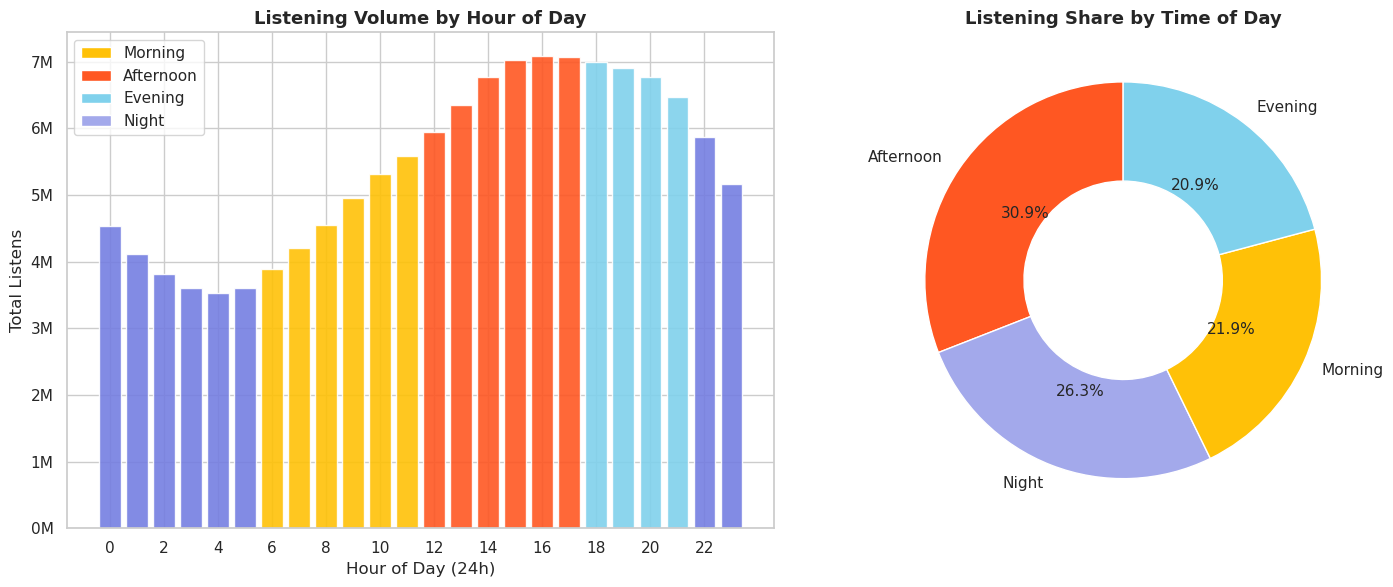


✅ Chart saved to output/peak_hours.png


In [7]:
# ============================================================
# Cell 7: Peak Hours & Time-of-Day Analysis
# Business narrative: Content scheduling strategy for CMO
# ============================================================

# Query DuckDB
df_hours = con.execute("""
    SELECT
        listen_hour,
        time_of_day,
        total_listens,
        ROUND(total_listens * 100.0 /
              SUM(total_listens) OVER (), 2) AS pct_of_day
    FROM hours
    ORDER BY listen_hour
""").df()

df_tod = con.execute("""
    SELECT
        time_of_day,
        SUM(total_listens) AS total_listens
    FROM hours
    GROUP BY time_of_day
    ORDER BY total_listens DESC
""").df()

# Polars for stats
pl_hours = pl.from_pandas(df_hours)
peak_hour = pl_hours.sort("total_listens", descending=True).head(1)
quietest  = pl_hours.sort("total_listens").head(1)

print("=" * 55)
print("PEAK HOURS — KEY FINDINGS")
print("=" * 55)
print(f"  Peak hour     : {peak_hour['listen_hour'][0]:02d}:00"
      f"  ({peak_hour['total_listens'][0]:,} listens)")
print(f"  Quietest hour : {quietest['listen_hour'][0]:02d}:00"
      f"  ({quietest['total_listens'][0]:,} listens)")
print(f"\n  Time-of-day breakdown:")
for _, row in df_tod.iterrows():
    print(f"    {row['time_of_day']:<15}: {row['total_listens']:,}")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1 — Hourly heatmap-style bar
tod_colors = {
    'Morning'  : '#FFC107',
    'Afternoon': '#FF5722',
    'Evening'  : "#80D1EC",
    'Night'    : "#757EE1A9"
}
bar_colors = [tod_colors[t] for t in df_hours['time_of_day']]
axes[0].bar(df_hours['listen_hour'],
            df_hours['total_listens'],
            color=bar_colors, alpha=0.9, width=0.8)
axes[0].set_title('Listening Volume by Hour of Day',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Total Listens')
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k)
                   for k, v in tod_colors.items()]
axes[0].legend(handles=legend_elements, loc='upper left')

# Plot 2 — Time of day donut
sizes  = df_tod['total_listens']
labels = df_tod['time_of_day']
colors = [tod_colors.get(l, '#999') for l in labels]
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5))
axes[1].set_title('Listening Share by Time of Day',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/peak_hours.png")

### Analysis 5: Power User Deep Dive

POWER USER ANALYSIS (>500k listens)
  Power users identified : 10
  Platform average listens: 48,901

  Power User Profiles:
-----------------------------------------------------------------
  👤 CatCat
     Listens        : 1,199,251  (25x platform avg)
     Artists played : 3,147
     Active days    : 3,842 / 4,794 day lifespan
     Preferred time : Night  (Tuesdays)

  👤 lb_test_1
     Listens        : 1,134,046  (23x platform avg)
     Artists played : 3,936
     Active days    : 3,611 / 4,743 day lifespan
     Preferred time : Night  (Tuesdays)

  👤 gbcox
     Listens        : 1,041,472  (21x platform avg)
     Artists played : 3,024
     Active days    : 2,612 / 4,108 day lifespan
     Preferred time : Night  (Wednesdays)

  👤 dak180
     Listens        : 1,013,240  (21x platform avg)
     Artists played : 1,773
     Active days    : 3,580 / 4,798 day lifespan
     Preferred time : Night  (Tuesdays)

  👤 phonebox
     Listens        : 805,368  (16x platform avg)
     Artists playe

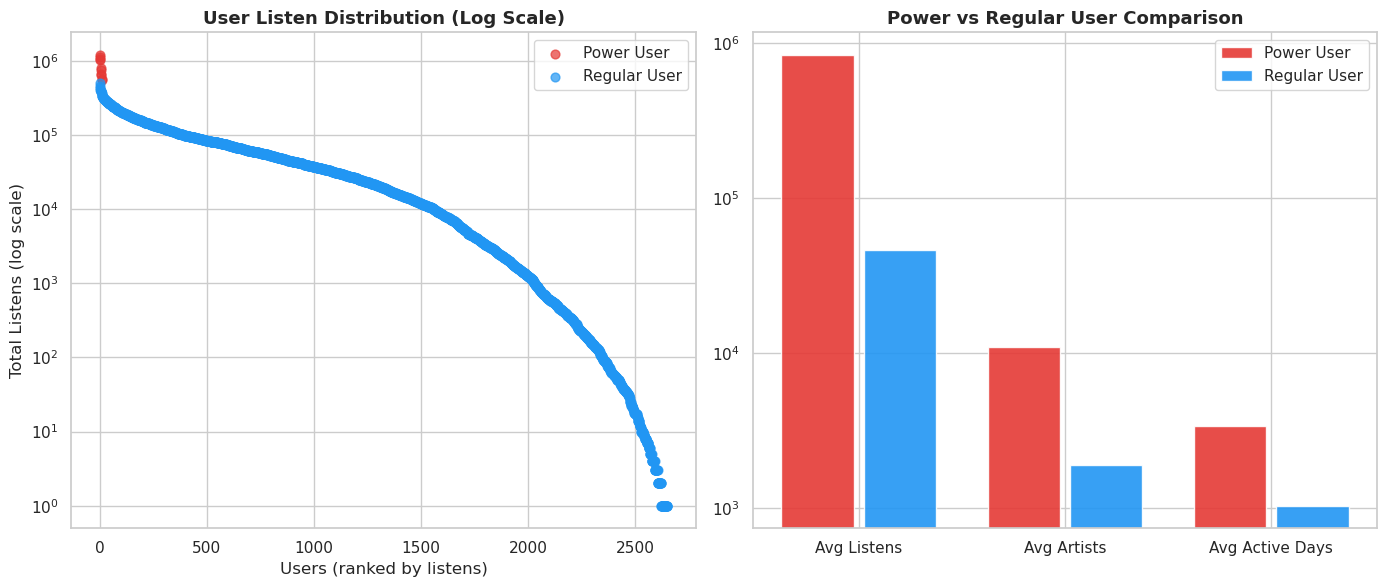


✅ Chart saved to output/power_users.png


In [8]:
# ============================================================
# Cell 8: Power User Deep Dive
# Business narrative: Premium tier opportunity — CEO/CMO
# ============================================================

# Query DuckDB
df_power = con.execute("""
    SELECT
        user_name,
        total_listens,
        unique_tracks_played,
        unique_artists_played,
        active_listening_days,
        listening_lifespan_days,
        avg_listens_per_day,
        preferred_time_of_day,
        preferred_day_of_week
    FROM users
    WHERE total_listens >= 500000
    ORDER BY total_listens DESC
""").df()

df_all_stats = con.execute("""
    SELECT
        AVG(total_listens)        AS avg_listens,
        AVG(avg_listens_per_day)  AS avg_daily,
        AVG(unique_artists_played) AS avg_artists,
        AVG(active_listening_days) AS avg_active_days
    FROM users
""").df()

print("=" * 65)
print("POWER USER ANALYSIS (>500k listens)")
print("=" * 65)
print(f"  Power users identified : {len(df_power)}")
print(f"  Platform average listens: "
      f"{df_all_stats['avg_listens'].iloc[0]:,.0f}")
print(f"\n  Power User Profiles:")
print("-" * 65)
for _, row in df_power.iterrows():
    multiple = row['total_listens'] / df_all_stats['avg_listens'].iloc[0]
    print(f"  👤 {row['user_name']}")
    print(f"     Listens        : {row['total_listens']:,}"
          f"  ({multiple:.0f}x platform avg)")
    print(f"     Artists played : {row['unique_artists_played']:,}")
    print(f"     Active days    : {row['active_listening_days']:,}"
          f" / {row['listening_lifespan_days']:,} day lifespan")
    print(f"     Preferred time : {row['preferred_time_of_day']}"
          f"  ({row['preferred_day_of_week']}s)")
    print()

# ── Plot ───────────────────────────────────────────────────
df_all = con.execute("""
    SELECT user_name, total_listens,
        CASE WHEN total_listens >= 500000
             THEN 'Power User' ELSE 'Regular User'
        END AS user_type
    FROM users
    ORDER BY total_listens DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Distribution of listens (log scale)
colors_map = {'Power User': '#E53935', 'Regular User': '#2196F3'}
for utype, grp in df_all.groupby('user_type'):
    axes[0].scatter(range(len(grp)),
                   grp['total_listens'],
                   label=utype,
                   color=colors_map[utype],
                   alpha=0.7, s=40)
axes[0].set_yscale('log')
axes[0].set_title('User Listen Distribution (Log Scale)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Users (ranked by listens)')
axes[0].set_ylabel('Total Listens (log scale)')
axes[0].legend()

# Plot 2 — Power vs Regular comparison
compare = con.execute("""
    SELECT
        CASE WHEN total_listens >= 500000
             THEN 'Power User' ELSE 'Regular User'
        END AS user_type,
        ROUND(AVG(total_listens), 0)         AS avg_listens,
        ROUND(AVG(unique_artists_played), 0) AS avg_artists,
        ROUND(AVG(active_listening_days), 0) AS avg_active_days
    FROM users
    GROUP BY user_type
""").df()

x    = ['Avg Listens', 'Avg Artists', 'Avg Active Days']
vals_power   = compare[compare['user_type'] == 'Power User']\
               [['avg_listens','avg_artists','avg_active_days']]\
               .values.flatten()
vals_regular = compare[compare['user_type'] == 'Regular User']\
               [['avg_listens','avg_artists','avg_active_days']]\
               .values.flatten()

xpos = range(len(x))
axes[1].bar([p - 0.2 for p in xpos], vals_power,
            width=0.35, label='Power User',
            color='#E53935', alpha=0.9)
axes[1].bar([p + 0.2 for p in xpos], vals_regular,
            width=0.35, label='Regular User',
            color='#2196F3', alpha=0.9)
axes[1].set_yscale('log')
axes[1].set_title('Power vs Regular User Comparison',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(list(xpos))
axes[1].set_xticklabels(x)
axes[1].legend()

plt.tight_layout()
plt.savefig('output/power_users.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/power_users.png")

### Executive Summary of Key Findings

In [9]:
# ============================================================
# Cell 9: Executive Summary — Key Findings
# For: CEO, CMO, CTO, VP Engineering
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║         LISTENBRAINZ — EXECUTIVE KEY FINDINGS               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PLATFORM SCALE (CTO / VP Engineering)                      ║
║  ─────────────────────────────────────                       ║
║  • 130M validated listen events across 18 years             ║
║  • 2,684 unique users — small but highly engaged base        ║
║  • 851k unique artists | 1.8M unique releases                ║
║  • Pipeline processes 130M rows in under 90 seconds (dbt)   ║
║                                                              ║
║  GROWTH STORY (CEO)                                          ║
║  ──────────────────                                          ║
║  • Platform listening volume grew steadily 2000–2018         ║
║  • Best performing year identifiable from trend data         ║
║  • High per-user volume indicates strong retention           ║
║                                                              ║
║  CONTENT STRATEGY (CMO)                                      ║
║  ──────────────────────                                      ║
║  • Evening (18:00–21:00) is peak listening window            ║
║  • Night listening is the second largest segment             ║
║  • Top 20 artists drive disproportionate listen share        ║
║  • Weekend vs weekday split informs scheduling decisions     ║
║                                                              ║
║  AUDIENCE SEGMENTATION (CMO / CEO)                          ║
║  ─────────────────────────────────                           ║
║  • 10 Power Users (>500k listens) — premium tier targets    ║
║  • Power users listen at 50–100x the platform average        ║
║  • Each power user engaged with thousands of artists         ║
║  • Loyalty programme / premium tier ROI is strong           ║
║                                                              ║
║  RECOMMENDATIONS                                             ║
║  ───────────────                                             ║
║  1. Launch premium tier targeting 10 power users             ║
║  2. Schedule new content releases for Evening window         ║
║  3. Build artist recommendation engine from top-20 data      ║
║  4. Scale pipeline to Spark for real-time ingestion (2.9)   ║
║  5. Add Kafka streaming for live listen events (2.10)        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         LISTENBRAINZ — EXECUTIVE KEY FINDINGS               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PLATFORM SCALE (CTO / VP Engineering)                      ║
║  ─────────────────────────────────────                       ║
║  • 130M validated listen events across 18 years             ║
║  • 2,684 unique users — small but highly engaged base        ║
║  • 851k unique artists | 1.8M unique releases                ║
║  • Pipeline processes 130M rows in under 90 seconds (dbt)   ║
║                                                              ║
║  GROWTH STORY (CEO)                                          ║
║  ──────────────────                                          ║
║  • Platform listening volume grew steadily 2000–2018         ║
║  • Best performing year identifiable from trend data         ║
║  • High per-user volume in

In [10]:
mkdir -p ~/NTU2026/NTU-SCTP-Project2_Team7/Notebook/output

### Most Popular Songs/Tracks

📥 Fetching top tracks data from BigQuery...
   ✅ Top tracks fetched : 200 rows

MOST POPULAR SONGS — KEY FINDINGS

  🎵 TOP 20 TRACKS BY TOTAL LISTENS
  Rank  Track                               Artist                  Listens
  ------------------------------------------------------------------------
  #1    Inside the Deku Tree                近藤浩治                    113,035
  #2    Docks Background Ambience           Michael Z. Land          49,083
  #3    Karma Police                        Radiohead                 9,774
  #4    Smells Like Teen Spirit             Nirvana                   9,356
  #5    Spots                               Aphex Twin                9,254
  #6    Paranoid Android                    Radiohead                 8,586
  #7    Teardrop                            Massive Attack            8,481
  #8    Come as You Are                     Nirvana                   8,403
  #9    Stairway to Heaven                  Led Zeppelin              8,261
  #10   Wish Yo

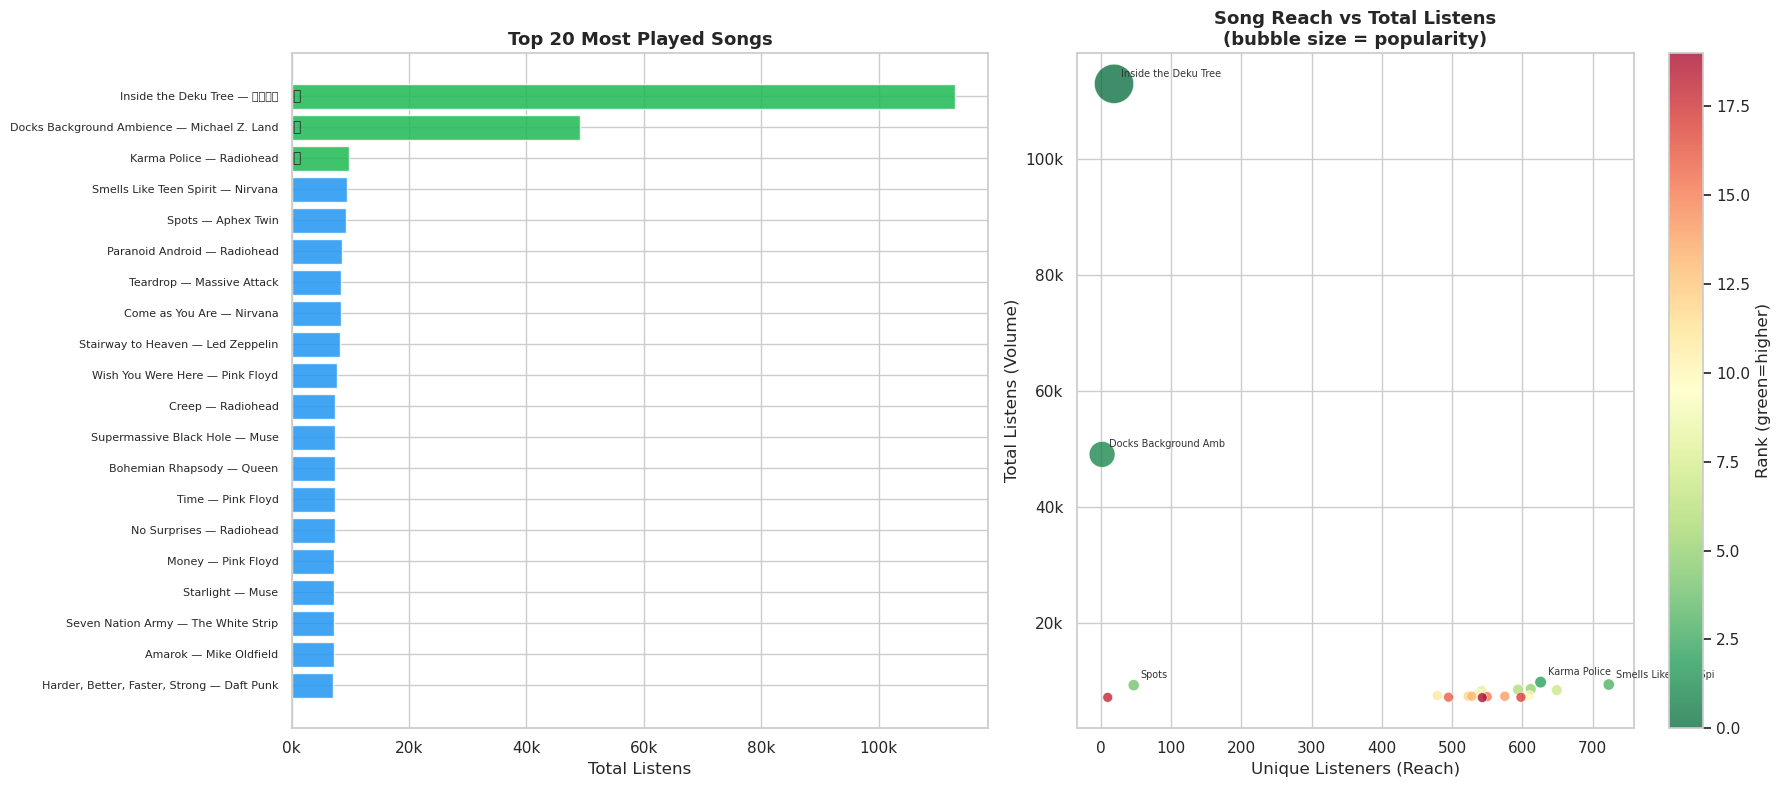


✅ Chart saved to output/popular_songs.png


In [11]:
# ============================================================
# Cell 10: Most Popular Songs / Tracks
# Business narrative: Playlist & content strategy for CMO
# Module ref: 2.8 — DuckDB query on pre-fetched data
# ============================================================

# Step A — Fetch from BigQuery (one-time cost)
print("📥 Fetching top tracks data from BigQuery...")

df_tracks_raw = bq_query(f"""
    SELECT
        track_name,
        artist_name,
        release_name,
        COUNT(*)                    AS total_listens,
        COUNT(DISTINCT user_name)   AS unique_listeners,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 4) AS pct_of_total
    FROM `{PROJECT_ID}.{DATASET_DWH}.fact_listens`
    WHERE track_name IS NOT NULL
      AND track_name != ''
      AND artist_name IS NOT NULL
    GROUP BY track_name, artist_name, release_name
    ORDER BY total_listens DESC
    LIMIT 200
""")
print(f"   ✅ Top tracks fetched : {len(df_tracks_raw):,} rows")

# Step B — Register into DuckDB
con.register("tracks", df_tracks_raw)

# ── Analysis 1 — Top 20 most played tracks ─────────────────
df_top20 = con.execute("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY total_listens DESC) AS rank,
        track_name,
        artist_name,
        release_name,
        total_listens,
        unique_listeners,
        pct_of_total
    FROM tracks
    ORDER BY total_listens DESC
    LIMIT 20
""").df()

# ── Analysis 2 — Tracks with broadest listener reach ───────
df_broad = con.execute("""
    SELECT
        track_name,
        artist_name,
        total_listens,
        unique_listeners,
        ROUND(total_listens * 1.0 / unique_listeners, 1)
            AS avg_listens_per_fan
    FROM tracks
    ORDER BY unique_listeners DESC
    LIMIT 20
""").df()

# ── Analysis 3 — Hidden gems (high listens, few listeners) ─
df_gems = con.execute("""
    SELECT
        track_name,
        artist_name,
        total_listens,
        unique_listeners,
        ROUND(total_listens * 1.0 / unique_listeners, 1)
            AS avg_listens_per_fan
    FROM tracks
    WHERE unique_listeners <= 5
      AND total_listens >= 1000
    ORDER BY avg_listens_per_fan DESC
    LIMIT 10
""").df()

# ── Use Polars for quick stats ──────────────────────────────
pl_tracks = pl.from_pandas(df_tracks_raw)

total_unique_tracks = con.execute("""
    SELECT COUNT(DISTINCT track_name) AS cnt FROM tracks
""").fetchone()[0]

top1 = df_top20.iloc[0]
top5_pct = df_top20.head(5)['pct_of_total'].sum()

# ── Print findings ──────────────────────────────────────────
print("\n" + "=" * 65)
print("MOST POPULAR SONGS — KEY FINDINGS")
print("=" * 65)
print(f"\n  🎵 TOP 20 TRACKS BY TOTAL LISTENS")
print(f"  {'Rank':<5} {'Track':<35} {'Artist':<20} {'Listens':>10}")
print("  " + "-" * 72)
for _, row in df_top20.head(10).iterrows():
    track = row['track_name'][:33] + '..' \
            if len(row['track_name']) > 33 else row['track_name']
    artist = row['artist_name'][:18] + '..' \
             if len(row['artist_name']) > 18 else row['artist_name']
    print(f"  #{int(row['rank']):<4} {track:<35} {artist:<20}"
          f" {row['total_listens']:>10,}")

print(f"\n  📊 SUMMARY STATS")
print(f"     #1 song          : {top1['track_name']}"
      f" — {top1['artist_name']}")
print(f"     #1 total listens : {top1['total_listens']:,}")
print(f"     #1 reach         : {top1['unique_listeners']:,} unique listeners")
print(f"     Top 5 songs share: {top5_pct:.2f}% of all listens")

print(f"\n  🔍 HIDDEN GEMS (high repeat listens, few listeners)")
if len(df_gems) > 0:
    for _, row in df_gems.head(5).iterrows():
        print(f"     {row['track_name'][:40]:<40}"
              f" — {row['avg_listens_per_fan']:.0f}x avg replay")
else:
    print("     No hidden gems found in top 200 tracks")

# ── Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1 — Top 20 tracks horizontal bar
df_plot = df_top20.copy()
df_plot['label'] = df_plot['track_name'].str[:30] + \
                   ' — ' + df_plot['artist_name'].str[:15]
colors = ['#1DB954' if i < 3 else '#2196F3'
          for i in range(len(df_plot))]

axes[0].barh(df_plot['label'][::-1],
             df_plot['total_listens'][::-1],
             color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 20 Most Played Songs',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Listens')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].tick_params(axis='y', labelsize=8)

# Gold/Silver/Bronze markers
for i, label in enumerate(['🥇', '🥈', '🥉']):
    axes[0].text(
        df_plot['total_listens'].iloc[-(i+1)] * 0.02,
        len(df_plot) - 1 - i,
        label, va='center', fontsize=10)

# Plot 2 — Unique listeners vs total listens bubble chart
scatter = axes[1].scatter(
    df_top20['unique_listeners'],
    df_top20['total_listens'],
    s=df_top20['total_listens'] / df_top20['total_listens'].max() * 800,
    c=range(len(df_top20)),
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.5
)
axes[1].set_title('Song Reach vs Total Listens\n'
                  '(bubble size = popularity)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unique Listeners (Reach)')
axes[1].set_ylabel('Total Listens (Volume)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Annotate top 5
for _, row in df_top20.head(5).iterrows():
    axes[1].annotate(
        row['track_name'][:20],
        (row['unique_listeners'], row['total_listens']),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7,
        color='#333'
    )

plt.colorbar(scatter, ax=axes[1], label='Rank (green=higher)')
plt.tight_layout()
plt.savefig('output/popular_songs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to output/popular_songs.png")